<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_6_(Exercise_6_3)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
 # Imports and Build a Digit-Indexed MNIST Pool

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_train = datasets.MNIST(root='./data', train=True,
                             download=True, transform=transform)

# Group images by digit so we can sample strips quickly
images_by_label = {d: [] for d in range(10)}
for img, label in mnist_train:
    if len(images_by_label[label]) < 600:
        images_by_label[label].append(img)
    if all(len(v) >= 600 for v in images_by_label.values()):
        break

print({d: len(v) for d, v in images_by_label.items()})

{0: 600, 1: 600, 2: 600, 3: 600, 4: 600, 5: 600, 6: 600, 7: 600, 8: 600, 9: 600}


In [6]:
# Strip Generator

n_slices = 8

def make_strip(images_by_label, n_slices=8, force_sevens=0):
    non_seven = [d for d in range(10) if d != 7]
    positions = list(range(n_slices))
    random.shuffle(positions)
    seven_positions = set(positions[:force_sevens])

    imgs = []
    for i in range(n_slices):
        if i in seven_positions:
            img = random.choice(images_by_label[7])
        else:
            d = random.choice(non_seven)
            img = random.choice(images_by_label[d])
        imgs.append(img)

    strip = torch.stack(imgs)                       # (n_slices, 1, 28, 28)
    label = 1.0 if force_sevens > 0 else 0.0
    return strip, label


def generate_strip_dataset(n_samples, images_by_label, n_slices=8):
    strips, labels = [], []
    for _ in range(n_samples):
        force = 1 if random.random() < 0.5 else 0
        strip, label = make_strip(images_by_label, n_slices, force_sevens=force)
        strips.append(strip)
        labels.append(label)
    return torch.stack(strips), torch.tensor(labels, dtype=torch.float32)


X_train, y_train = generate_strip_dataset(1500, images_by_label, n_slices)
X_test,  y_test  = generate_strip_dataset(300,  images_by_label, n_slices)

print(f"X_train: {X_train.shape}, y_train mean: {y_train.mean():.2f}")

X_train: torch.Size([1500, 8, 1, 28, 28]), y_train mean: 0.48


In [7]:
# Image Encoder, Soft-Attention Pool (from 6.2), Multi-Head Cross-Attention

class ImageEncoder(nn.Module):
    def __init__(self, d_model=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Linear(32 * 7 * 7, d_model)

    def forward(self, x):
        h = self.conv(x)
        h = h.view(h.size(0), -1)
        return self.fc(h)


class SoftAttentionPool(nn.Module):
    def __init__(self, d_model, hidden=32):
        super().__init__()
        self.score_mlp = nn.Sequential(
            nn.Linear(d_model, hidden), nn.Tanh(),
            nn.Linear(hidden, 1)
        )

    def forward(self, e):
        w     = self.score_mlp(e).squeeze(-1)     # (B, n)
        alpha = F.softmax(w, dim=-1)                # (B, n)
        Q     = torch.einsum('bn,bnd->bd', alpha, e) # (B, d)
        return Q, alpha


class MultiHeadCrossAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, query, kv_seq):
        """
        query:  (B, 1, d_model)  — the pooled vector, treated as ONE query
        kv_seq: (B, n, d_model)  — original sequence, used as K and V
        """
        B = query.shape[0]
        n = kv_seq.shape[1]

        Q = self.W_q(query)    # (B, 1, d_model)
        K = self.W_k(kv_seq)   # (B, n, d_model)
        V = self.W_v(kv_seq)   # (B, n, d_model)

        Q = Q.view(B, 1, self.n_heads, self.d_k).transpose(1, 2)  # (B, h, 1, d_k)
        K = K.view(B, n, self.n_heads, self.d_k).transpose(1, 2)  # (B, h, n, d_k)
        V = V.view(B, n, self.n_heads, self.d_k).transpose(1, 2)  # (B, h, n, d_k)

        scores  = Q @ K.transpose(-2, -1) / np.sqrt(self.d_k)     # (B, h, 1, n)
        weights = F.softmax(scores, dim=-1)
        out     = weights @ V                                     # (B, h, 1, d_k)

        out = out.transpose(1, 2).contiguous().view(B, 1, self.d_model)
        out = self.W_o(out).squeeze(1)        # (B, d_model)

        return out, weights.squeeze(2)        # (B, d_model), (B, h, n)

In [8]:
# Full Model

class StripModel(nn.Module):
    def __init__(self, d_model=64, n_heads=4):
        super().__init__()
        self.encoder    = ImageEncoder(d_model)
        self.pool       = SoftAttentionPool(d_model)
        self.cross_attn = MultiHeadCrossAttention(d_model, n_heads)
        self.classifier = nn.Linear(d_model, 1)

    def forward(self, strip):
        """ strip: (B, n_slices, 1, 28, 28) """
        B, n, C, H, W = strip.shape
        flat = strip.view(B * n, C, H, W)
        emb  = self.encoder(flat).view(B, n, -1)        # (B, n, d_model)

        Q_init, alpha_pool = self.pool(emb)              # (B, d_model), (B, n)
        Q_init = Q_init.unsqueeze(1)                      # (B, 1, d_model)

        Q_refined, alpha_cross = self.cross_attn(Q_init, emb)  # (B,d), (B,h,n)

        logit = self.classifier(Q_refined).squeeze(-1)
        return logit, alpha_pool, alpha_cross

In [9]:
# Train

model     = StripModel(d_model=64, n_heads=4)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

n_epochs   = 15
batch_size = 64
n_batches  = len(X_train) // batch_size

for epoch in range(n_epochs):
    perm = torch.randperm(len(X_train))
    total_loss = 0
    for b in range(n_batches):
        idx = perm[b*batch_size:(b+1)*batch_size]
        xb, yb = X_train[idx], y_train[idx]

        logit, _, _ = model(xb)
        loss = criterion(logit, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    with torch.no_grad():
        test_logit, _, _ = model(X_test)
        test_acc = ((torch.sigmoid(test_logit) > 0.5).float() == y_test).float().mean()

    print(f"Epoch {epoch+1}/{n_epochs} | Loss: {total_loss/n_batches:.4f} | Test acc: {test_acc*100:.1f}%")

Epoch 1/15 | Loss: 0.6946 | Test acc: 47.0%
Epoch 2/15 | Loss: 0.6800 | Test acc: 86.7%
Epoch 3/15 | Loss: 0.3472 | Test acc: 92.0%
Epoch 4/15 | Loss: 0.1902 | Test acc: 95.0%
Epoch 5/15 | Loss: 0.1314 | Test acc: 95.7%
Epoch 6/15 | Loss: 0.0951 | Test acc: 94.7%
Epoch 7/15 | Loss: 0.0618 | Test acc: 97.0%
Epoch 8/15 | Loss: 0.0410 | Test acc: 97.0%
Epoch 9/15 | Loss: 0.0298 | Test acc: 98.0%
Epoch 10/15 | Loss: 0.0109 | Test acc: 98.3%
Epoch 11/15 | Loss: 0.0054 | Test acc: 98.7%
Epoch 12/15 | Loss: 0.0013 | Test acc: 98.7%
Epoch 13/15 | Loss: 0.0009 | Test acc: 98.7%
Epoch 14/15 | Loss: 0.0005 | Test acc: 98.7%
Epoch 15/15 | Loss: 0.0002 | Test acc: 98.7%


In [10]:
# Build Three Comparison Strips

strip_one_seven, _  = make_strip(images_by_label, n_slices, force_sevens=1)
strip_no_seven,  _  = make_strip(images_by_label, n_slices, force_sevens=0)
strip_two_sevens, _ = make_strip(images_by_label, n_slices, force_sevens=2)

comparison_strips = {
    'one 7':  strip_one_seven,
    'no 7':   strip_no_seven,
    'two 7s': strip_two_sevens
}

model.eval()
results = {}
with torch.no_grad():
    for name, strip in comparison_strips.items():
        logit, alpha_pool, alpha_cross = model(strip.unsqueeze(0))
        prob = torch.sigmoid(logit).item()
        results[name] = {
            'images':      strip,
            'prob':        prob,
            'alpha_pool':  alpha_pool[0].numpy(),
            'alpha_cross': alpha_cross[0].numpy()   # (h, n)
        }
        print(f"{name:<10} | predicted P(contains 7) = {prob:.3f}")

one 7      | predicted P(contains 7) = 1.000
no 7       | predicted P(contains 7) = 0.000
two 7s     | predicted P(contains 7) = 1.000


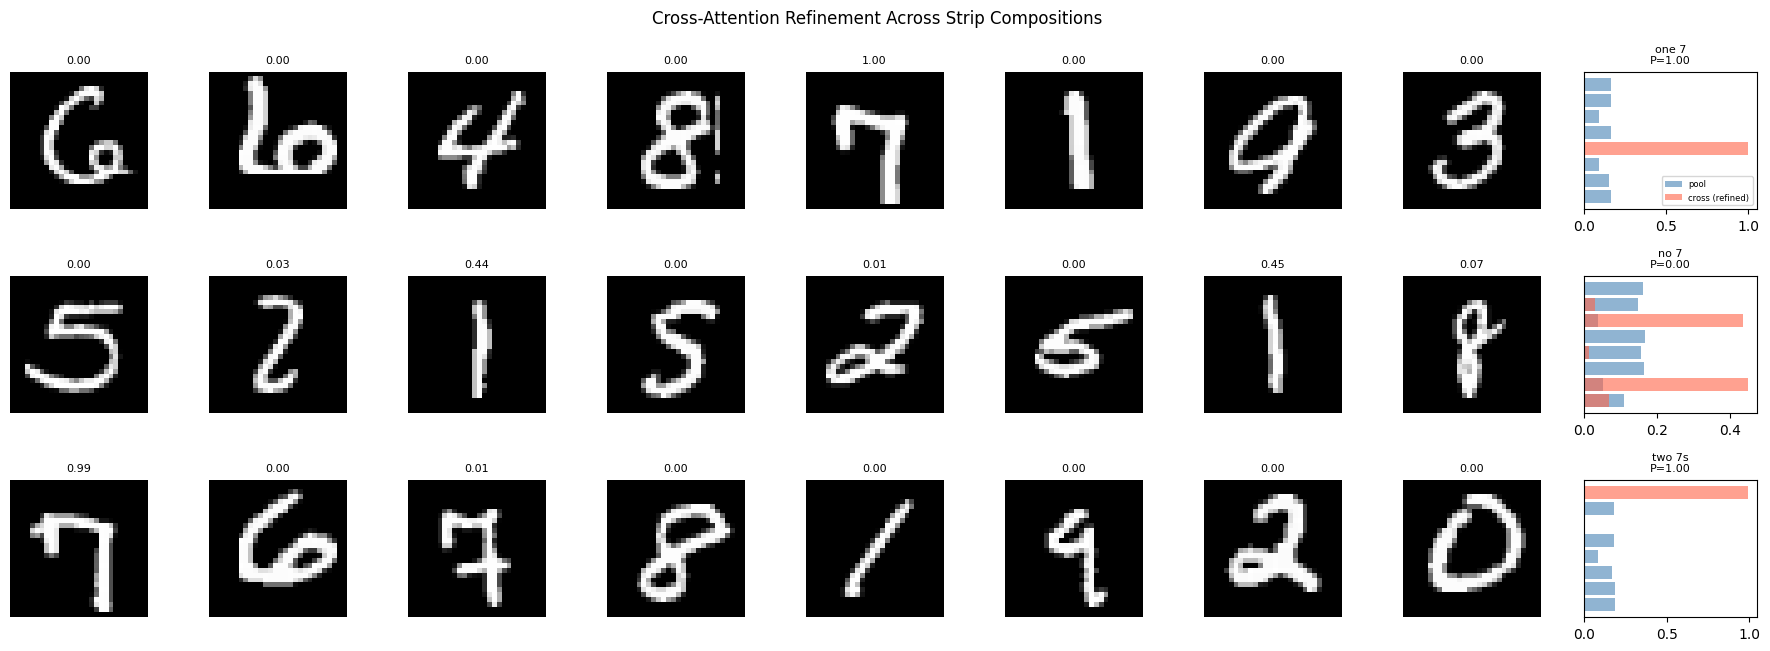

In [11]:
# Visualise: Images + Pooled Weights + Cross-Attention Weights

fig, axes = plt.subplots(len(comparison_strips), n_slices + 1,
                         figsize=(2.0 * (n_slices + 1), 2.2 * len(comparison_strips)))

for row, (name, data) in enumerate(results.items()):
    for col in range(n_slices):
        axes[row, col].imshow(data['images'][col, 0].numpy(), cmap='gray')
        axes[row, col].axis('off')
        axes[row, col].set_title(f"{data['alpha_cross'].mean(0)[col]:.2f}",
                                  fontsize=8)

    mean_cross = data['alpha_cross'].mean(axis=0)   # average over heads
    axes[row, -1].barh(range(n_slices), data['alpha_pool'][::-1],
                       color='steelblue', alpha=0.6, label='pool')
    axes[row, -1].barh(range(n_slices), mean_cross[::-1],
                       color='tomato', alpha=0.6, label='cross (refined)')
    axes[row, -1].set_yticks([])
    axes[row, -1].set_title(f"{name}\nP={data['prob']:.2f}", fontsize=8)
    if row == 0:
        axes[row, -1].legend(fontsize=6, loc='lower right')

plt.suptitle('Cross-Attention Refinement Across Strip Compositions', fontsize=12)
plt.tight_layout()
plt.savefig('cross_attn_6_3.png', dpi=150)
plt.show()

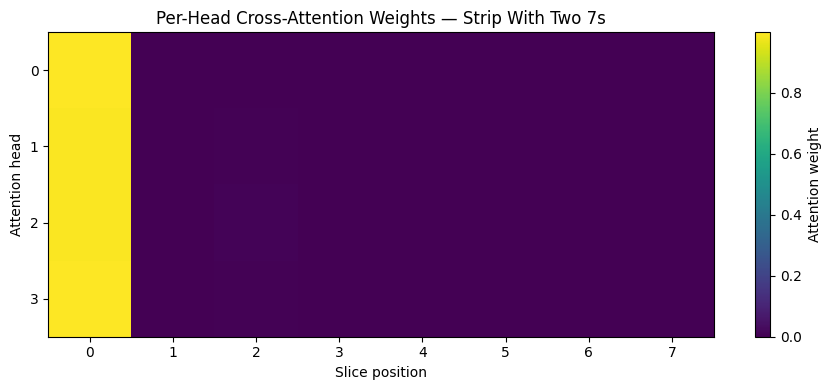

In [12]:
#  Per-Head Breakdown for the "two 7s" Strip

two_sevens_cross = results['two 7s']['alpha_cross']   # (n_heads, n_slices)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(two_sevens_cross, cmap='viridis', aspect='auto')
ax.set_xlabel('Slice position')
ax.set_ylabel('Attention head')
ax.set_title('Per-Head Cross-Attention Weights — Strip With Two 7s')
ax.set_yticks(range(two_sevens_cross.shape[0]))
plt.colorbar(im, ax=ax, label='Attention weight')
plt.tight_layout()
plt.savefig('per_head_6_3.png', dpi=150)
plt.show()

# Interpretation And Observation

#### Cross-attention correctly and sharply located the single informative slice when exactly one seven was present, assigning it a weight of 1.00 regardless of its position in the strip, and correctly produced a diffuse, low-confidence attention pattern with prediction near 0.50 when no seven was present at all. When two sevens were present simultaneously, all four attention heads collapsed onto only one of them with weight 0.99, entirely ignoring the second. This is not evidence that the mechanism is structurally incapable of attending to multiple informative positions at once — Exercise 6.2's attention profile already demonstrated the opposite, producing a flat, evenly elevated plateau across the entire 41-55 informative region precisely because every slice in that band carried an identical injected signal and therefore received near-tied scores. The difference in 6.3 is that the two sevens were independent real handwriting samples passed through a full CNN encoder, almost certainly producing two embeddings with a small but genuine difference between them, and softmax's exponential nature is what turns that small real gap into near-total commitment to one over the other. The accurate finding, then, is narrower than a general claim about cross-attention's capacity: the mechanism distributes weight fairly across positions with near-tied informativeness, but is vulnerable to amplifying even a small real difference between two equally relevant candidates into a near-complete winner-take-all split. Whether this vulnerability actually manifests in LDAE's real two-stage SoftAttention–CrossAttention encoder — for instance, with bilateral hippocampal atrophy appearing as two anatomically separated but equally diagnostic regions — is an open empirical question that this toy MNIST result cannot answer on its own, since it depends on how similarly or differently real pathological regions score once passed through the actual ConvNeXt-Small slice encoder, which has not been tested here.